# Run comparison

Each entry in `RUNS` is a label mapped to one or more run directories, `.npz` files, or
legacy `.npy` files. Relative paths resolve from the repository root.

A run directory loads **every seed it contains**, discovered from the per-seed files
(`training_rewards_seed<N>.npz`, or `seed<N>/training_rewards.npz` for a seed that was
interrupted). The aggregate `training_rewards.npz` is only a fallback: it covers the
seeds of the most recent invocation, so a resumed run overwrites it and silently drops
the earlier seeds.

Set `SKIP_MISSING = True` while a sweep is still running, so the widths that have
finished plot without waiting for the rest.

In [4]:
RUNS = {
    "NPG 4x4": ["runs_new/Swimmer/npg/4x4"],
    "NPG 8x8": ["runs_new/Swimmer/npg/8x8"],
    "NPG 16x16": ["runs_new/Swimmer/npg/16x16"],
}

MEAN_TITLE = "Swimmer network-width comparison"
BEST_TITLE = "Swimmer best-seed comparison"
XLABEL = "Iteration"
YLABEL = "Average training return"
MEAN_OUTPUT = "runs_new/Swimmer/comparison.png"
BEST_OUTPUT = "runs_new/Swimmer/best_seed_comparison.png"

# Iterations averaged to score each seed (picks the curve for the best-seed plot).
FINAL_WINDOW = 100

# Drop groups whose files do not exist yet instead of raising.
SKIP_MISSING = True

# Clip to the shortest curve when groups ran a different number of iterations.
# False raises instead, so comparing a 1200-iteration run against a 600-iteration
# one is never silent -- the shorter run would look like it plateaued early.
TRUNCATE = False

In [5]:
import sys
from pathlib import Path

import numpy as np
from IPython.display import Image, display

working_dir = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in (working_dir, *working_dir.parents)
        if (path / "vpg" / "analysis.py").is_file()
    ),
    None,
)
if repo_root is None:
    raise FileNotFoundError(
        f"Could not locate the repository root containing vpg/analysis.py "
        f"(searched upwards from {working_dir})"
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from vpg.analysis import load_reward_files, plot_comparison
from vpg.stats import student_t_critical_95


def from_repo_root(path):
    path = Path(path).expanduser()
    return path.resolve() if path.is_absolute() else (repo_root / path).resolve()


def load_groups(runs, skip_missing=True, truncate=False):
    """Load each labeled group, optionally skipping ones with no files yet."""
    groups, missing = {}, {}
    for label, inputs in runs.items():
        try:
            groups[label] = load_reward_files(
                [from_repo_root(path) for path in inputs], truncate=truncate
            )
        except FileNotFoundError as exc:
            if not skip_missing:
                raise
            missing[label] = exc

    for label, exc in missing.items():
        print(f"skipped {label}: {exc}")
    if not groups:
        raise FileNotFoundError("No run in RUNS has any reward files yet")
    return groups


def summarize(groups, final_window=100):
    """Print per-seed scores and the mean/CI for every group.

    Seed counts are shown per group: an unequal n across widths makes the
    intervals unequally trustworthy, which the plot itself does not convey.
    """
    for label, data in groups.items():
        window = min(final_window, data.curves.shape[1])
        scores = data.curves[:, -window:].mean(axis=1)
        order = np.argsort(scores)[::-1]

        print(f"{label}  ({len(scores)} seeds x {data.curves.shape[1]} iterations)")
        for index in order:
            marker = "  <- best" if index == order[0] else ""
            print(f"    {data.labels[index]:>12}  {scores[index]:8.2f}{marker}")
        if len(scores) > 1:
            sd = scores.std(ddof=1)
            half = student_t_critical_95(len(scores)) * sd / np.sqrt(len(scores))
            print(
                f"    final-{window}: {scores.mean():.2f} +/-{half:.2f} "
                f"(sd {sd:.2f}, n={len(scores)})"
            )
        else:
            print(f"    final-{window}: {scores.mean():.2f} (single seed, no CI)")
        print()

NPG 4x4  (6 seeds x 1200 iterations)
         seed 26    123.79  <- best
         seed 23    121.64
         seed 27     61.22
         seed 24     37.95
         seed 28     32.87
         seed 25     29.62
    final-100: 67.85 +/-46.09 (sd 43.92, n=6)

NPG 8x8  (6 seeds x 1200 iterations)
         seed 23    106.30  <- best
         seed 25    106.03
         seed 28    100.29
         seed 26     99.01
         seed 27     96.46
         seed 24     63.88
    final-100: 95.33 +/-16.68 (sd 15.90, n=6)

NPG 16x16  (6 seeds x 1200 iterations)
         seed 23    120.07  <- best
         seed 24    107.67
         seed 27     91.10
         seed 28     85.07
         seed 26     82.53
         seed 25     81.56
    final-100: 94.66 +/-16.52 (sd 15.74, n=6)

saved mean comparison: runs_new/Swimmer/comparison.png


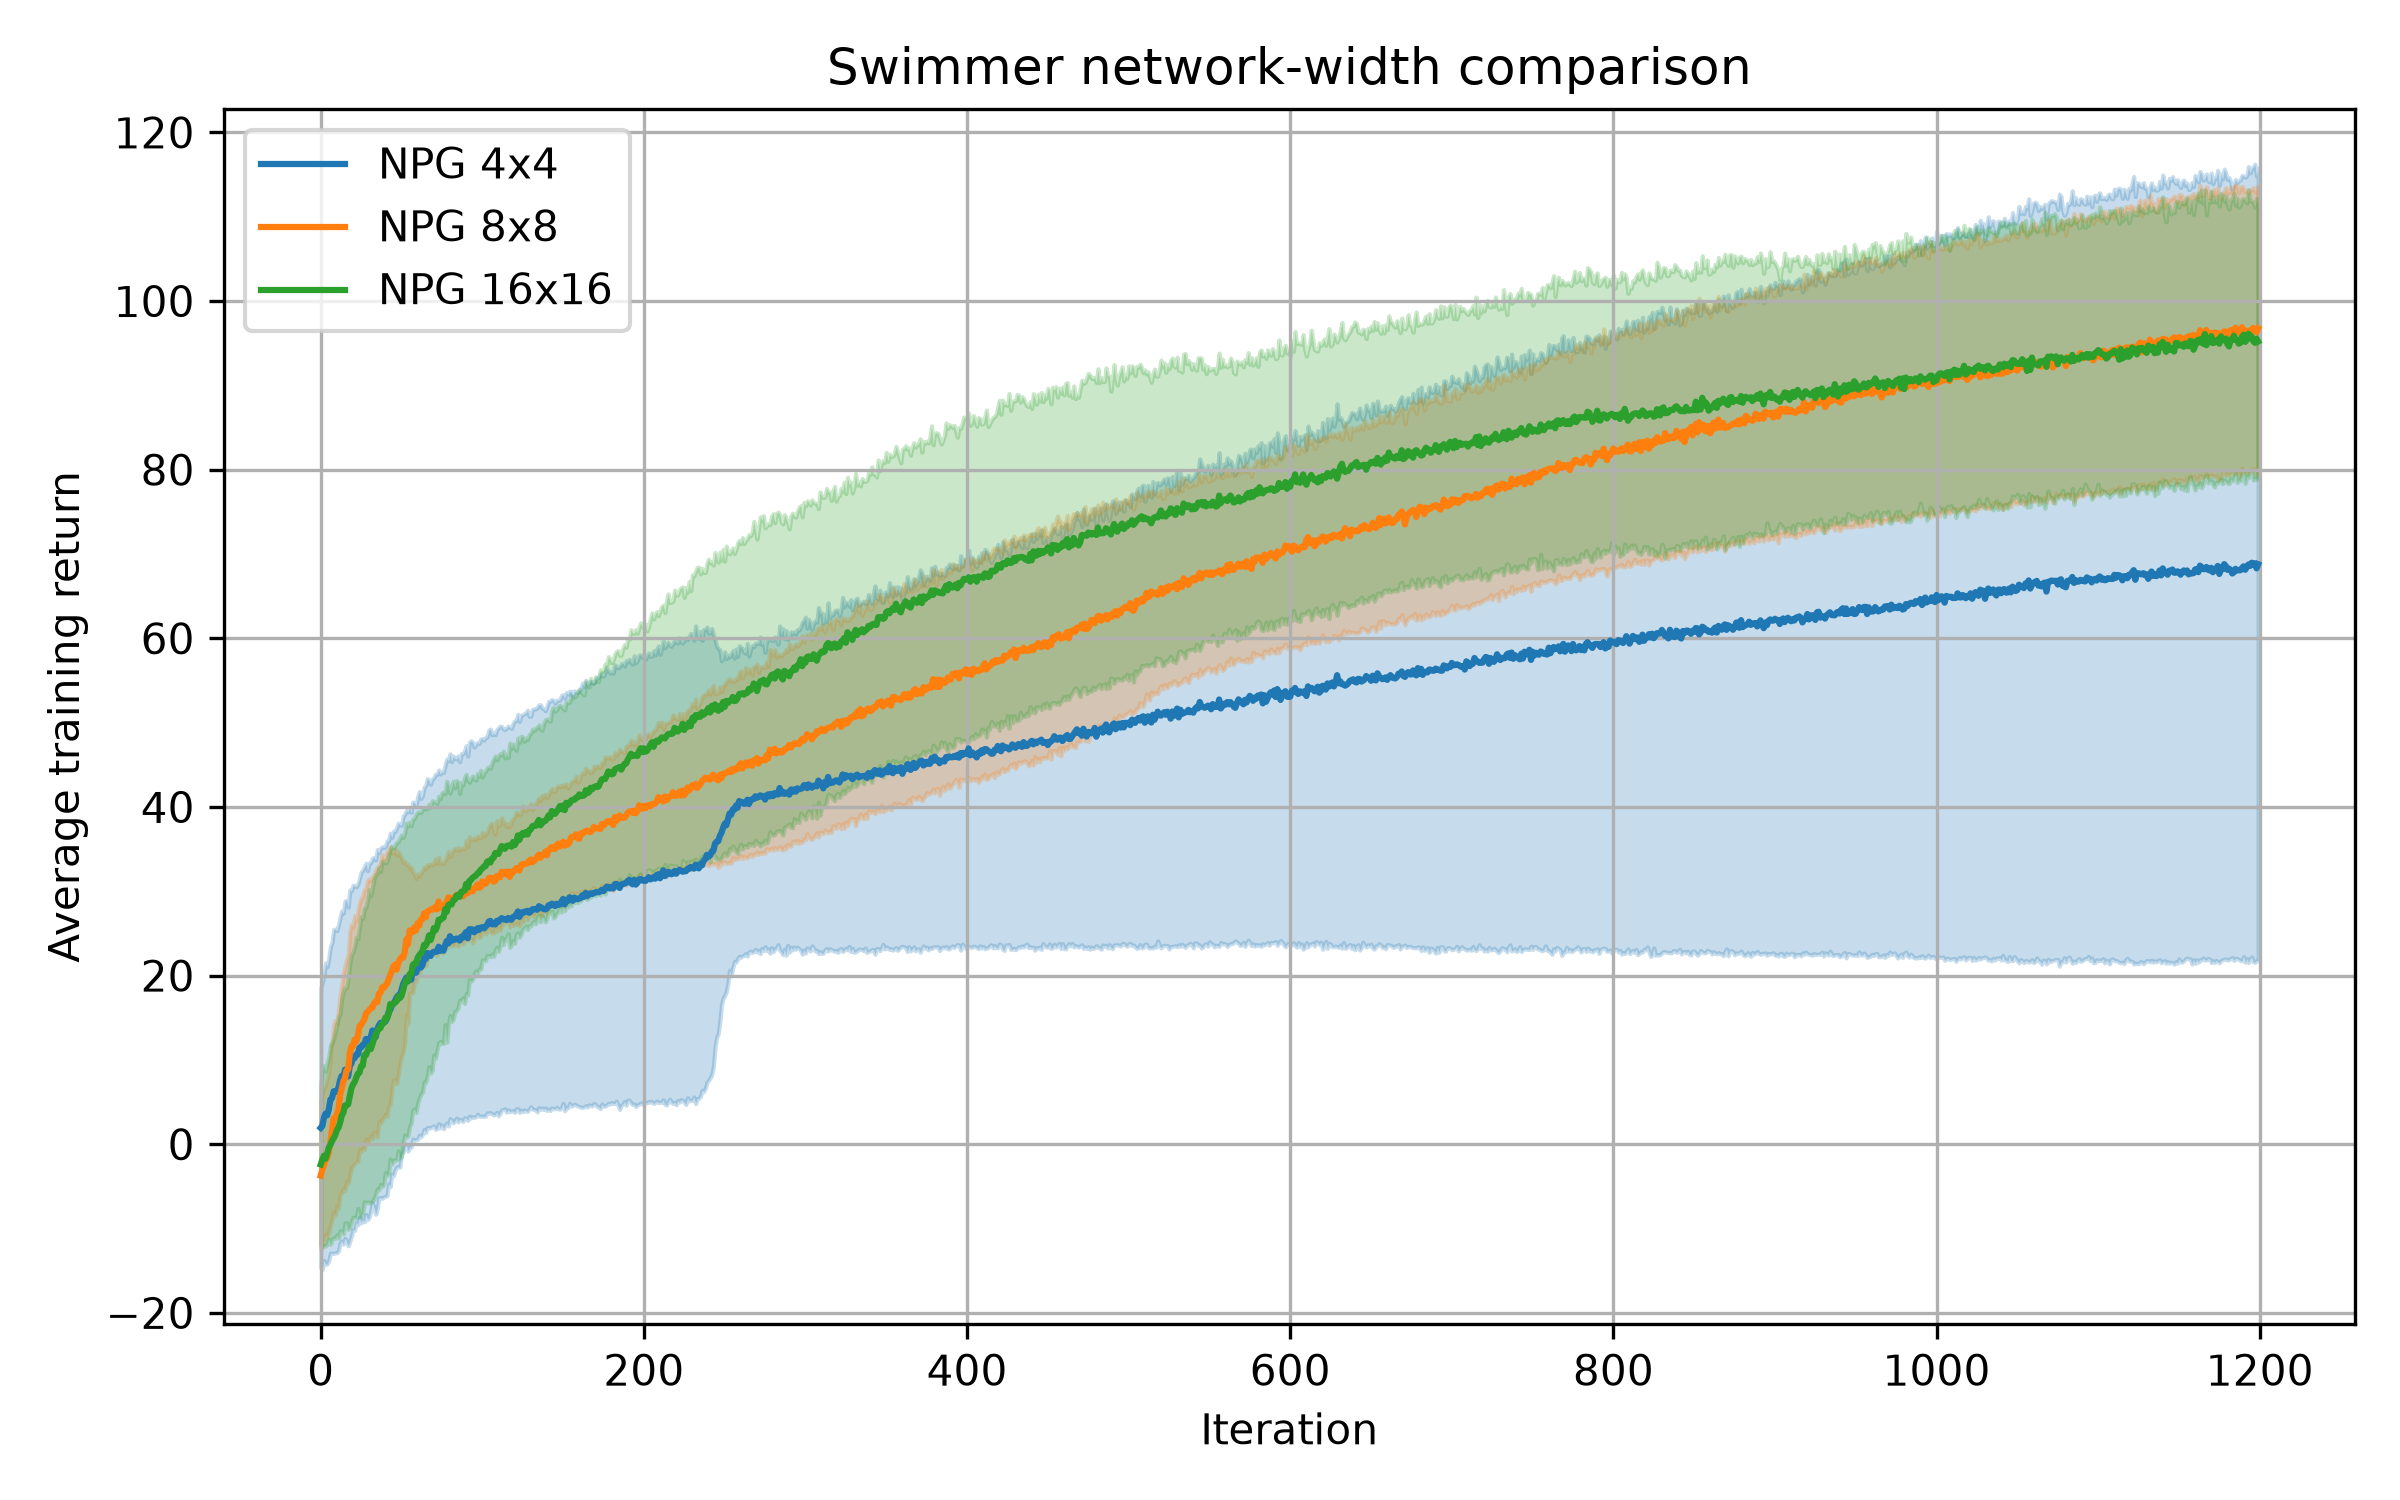

saved best-seed comparison: runs_new/Swimmer/best_seed_comparison.png


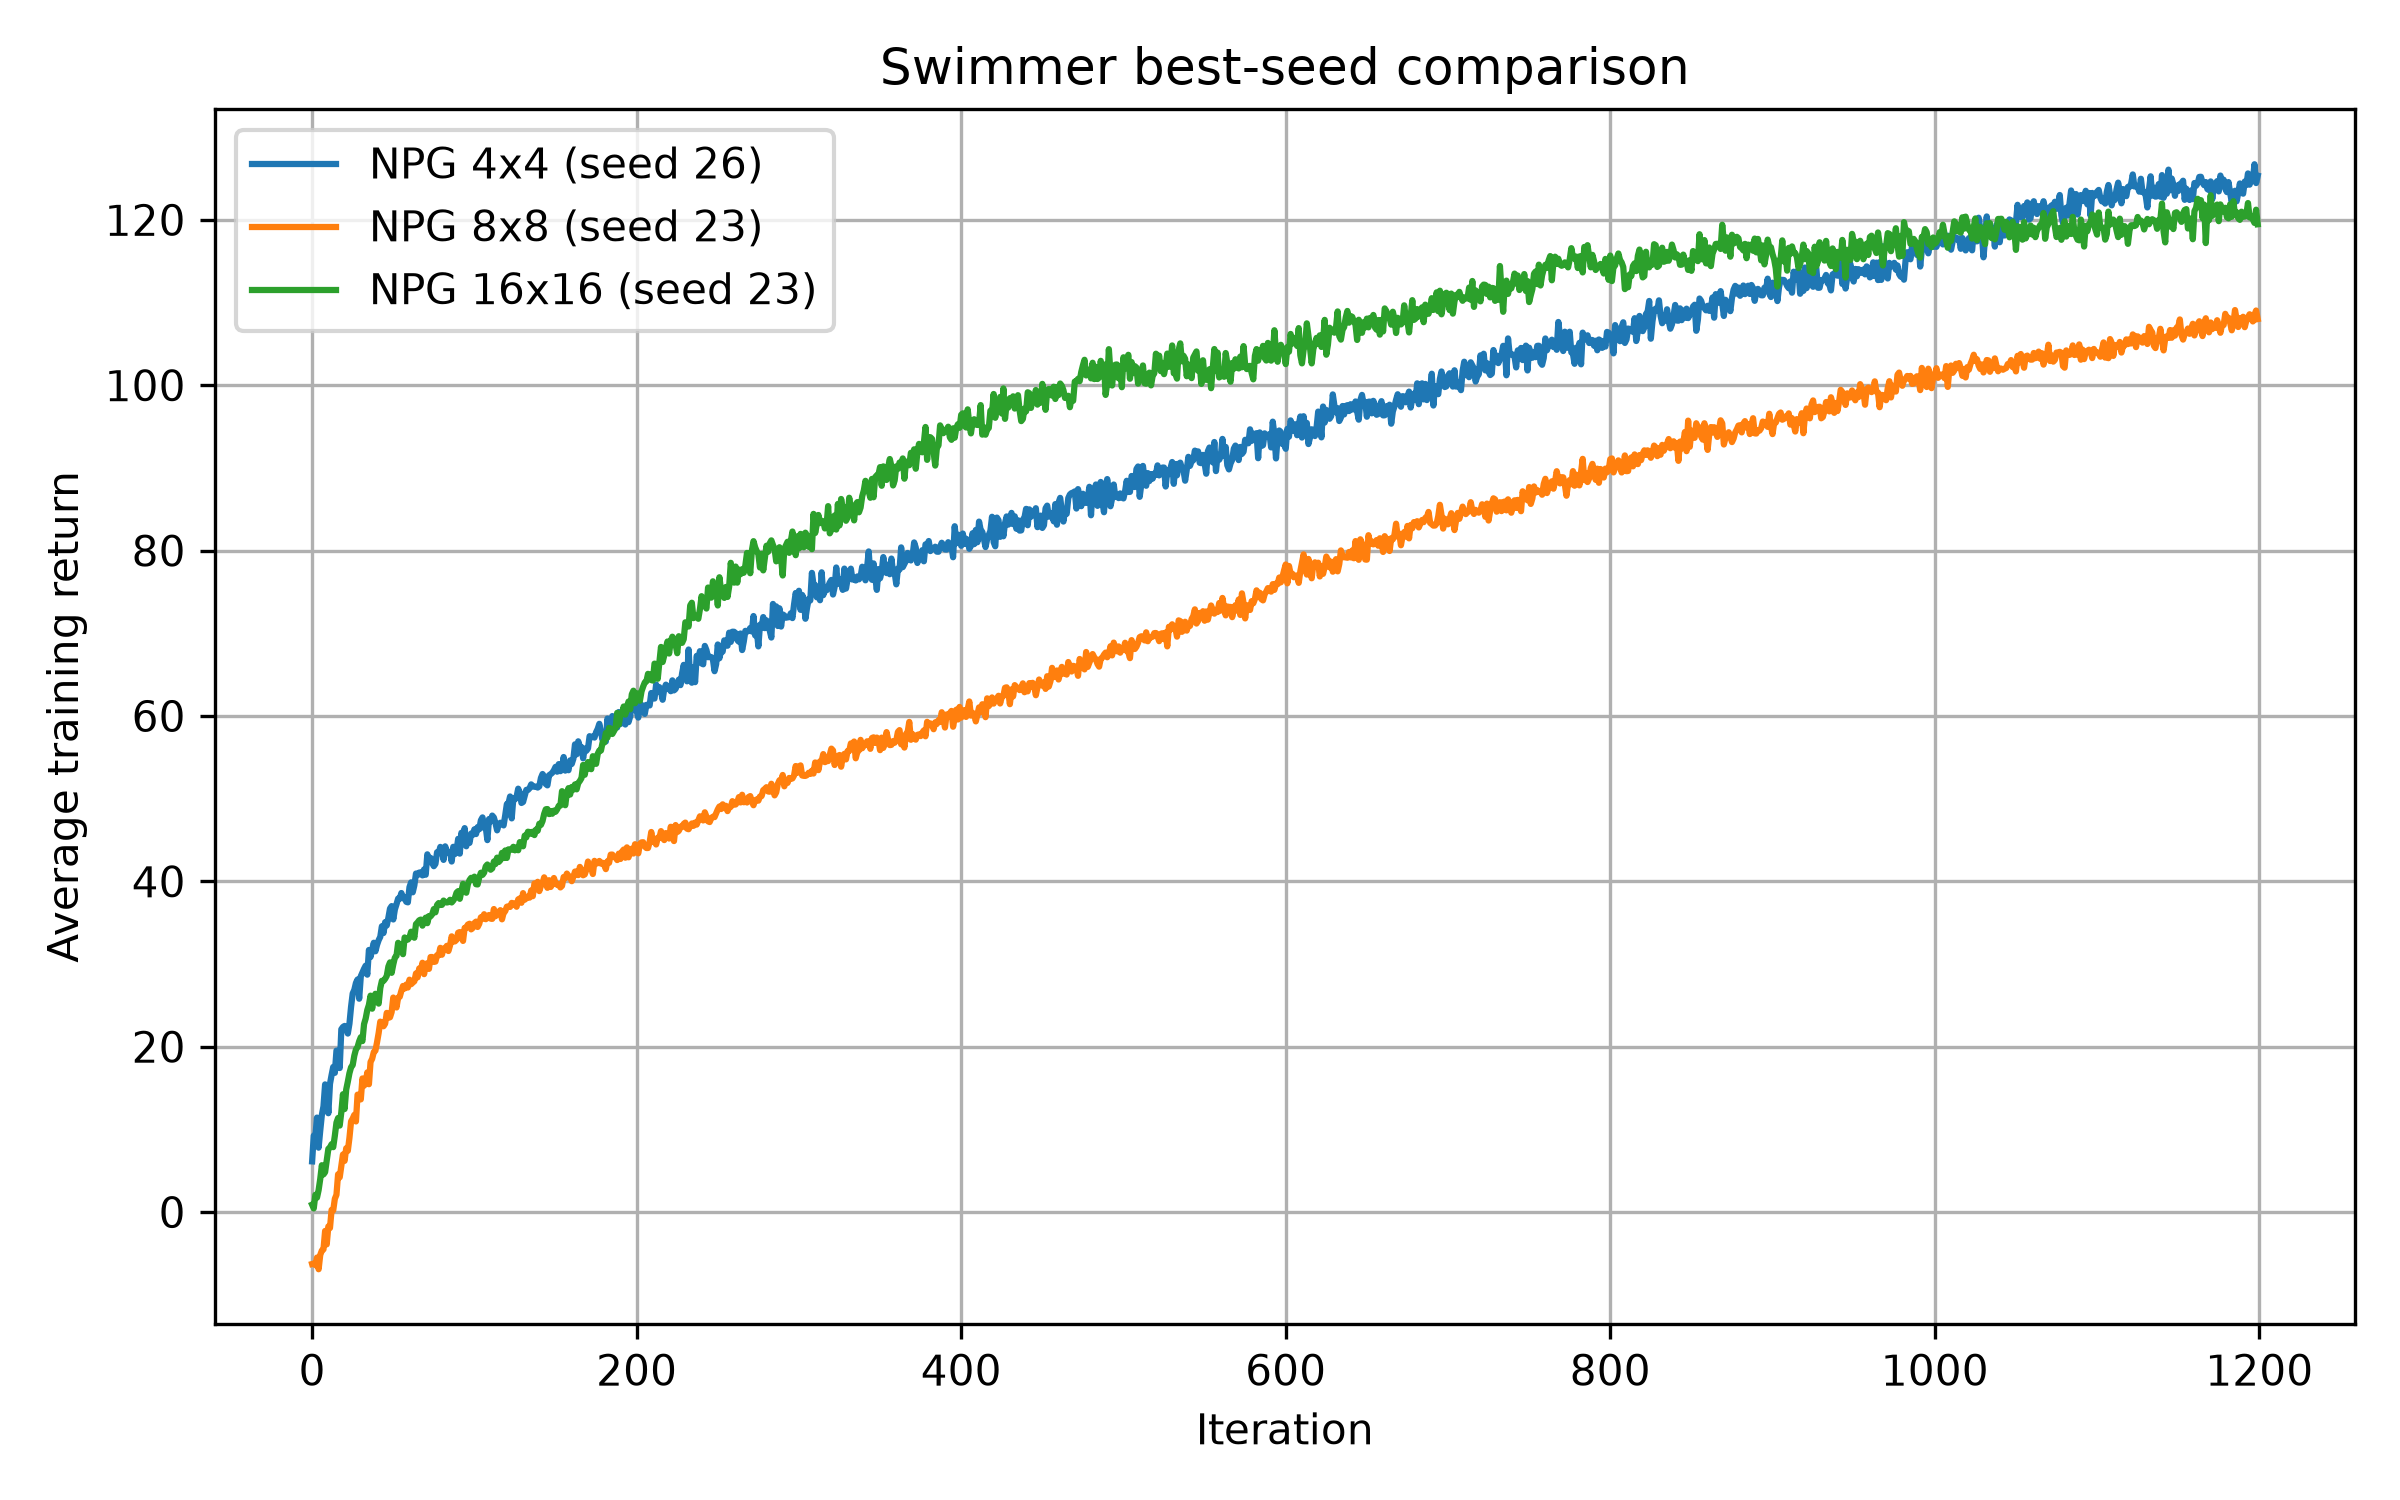

In [6]:
if FINAL_WINDOW <= 0:
    raise ValueError("FINAL_WINDOW must be greater than zero")

groups = load_groups(RUNS, skip_missing=SKIP_MISSING, truncate=TRUNCATE)
summarize(groups, FINAL_WINDOW)

mean_path = plot_comparison(
    groups,
    from_repo_root(MEAN_OUTPUT),
    title=MEAN_TITLE,
    xlabel=XLABEL,
    ylabel=YLABEL,
    mode="mean",
    final_window=FINAL_WINDOW,
    truncate=TRUNCATE,
)
best_path = plot_comparison(
    groups,
    from_repo_root(BEST_OUTPUT),
    title=BEST_TITLE,
    xlabel=XLABEL,
    ylabel=YLABEL,
    mode="best",
    final_window=FINAL_WINDOW,
    truncate=TRUNCATE,
)

print(f"saved mean comparison: {mean_path.relative_to(repo_root)}")
display(Image(filename=str(mean_path)))
print(f"saved best-seed comparison: {best_path.relative_to(repo_root)}")
display(Image(filename=str(best_path)))